# Regressão Logística para Risco de Crédito com PyCaret

Pipeline completo: base simulada → `setup` → `create_model('lr')` → tuning → métricas de crédito (AUC, Gini, KS, tabela de decis) → coeficientes/odds ratios → salvar e reutilizar o modelo.

**Requisitos:** Python 3.9–3.11 (PyCaret 3.x não roda em 3.12+). Recomendado usar um venv dedicado.

In [1]:
# Rode uma vez. Se já tiver o pycaret instalado, pule.
!pip install pycaret

In [2]:
import numpy as np
import pandas as pd
import pycaret
print("PyCaret", pycaret.__version__)

PyCaret 3.3.2


## 1. Base simulada
Variáveis típicas de PF (idade, renda, tempo de emprego, utilização de limite, atrasos, comprometimento de renda, consultas, ocupação, imóvel). O `default` é gerado a partir de um logit conhecido — útil para checar se o modelo recupera os sinais esperados.

In [3]:
rng = np.random.default_rng(42)
n = 10_000

idade          = rng.integers(21, 70, n)
renda          = rng.lognormal(8.2, 0.5, n).round(0)      # mediana ~ R$ 3.600
tempo_emprego  = rng.exponential(5, n).round(1)           # anos
utilizacao     = rng.beta(2, 3, n).round(3)               # % do limite usado
n_atrasos_12m  = rng.poisson(0.4, n)
dti            = rng.beta(2, 5, n).round(3)               # comprometimento de renda
consultas_6m   = rng.poisson(1.2, n)
tipo_ocupacao  = rng.choice(['CLT', 'autonomo', 'servidor', 'aposentado'], n, p=[.50, .25, .15, .10])
possui_imovel  = rng.integers(0, 2, n)

efeito_ocup = pd.Series(tipo_ocupacao).map({'CLT': 0.0, 'autonomo': 0.4, 'servidor': -0.5, 'aposentado': -0.3}).values

logit = (-3.0
         - 0.02 * (idade - 40)
         - 0.40 * np.log(renda / 3600)
         - 0.05 * tempo_emprego
         + 2.00 * utilizacao
         + 0.60 * n_atrasos_12m
         + 2.50 * dti
         + 0.25 * consultas_6m
         - 0.50 * possui_imovel
         + efeito_ocup
         + rng.normal(0, 0.3, n))

pd_true = 1 / (1 + np.exp(-logit))
default = rng.binomial(1, pd_true)

df = pd.DataFrame({
    'idade': idade, 'renda': renda, 'tempo_emprego': tempo_emprego,
    'utilizacao': utilizacao, 'n_atrasos_12m': n_atrasos_12m, 'dti': dti,
    'consultas_6m': consultas_6m, 'tipo_ocupacao': tipo_ocupacao,
    'possui_imovel': possui_imovel, 'default': default,
})
print(f"Taxa de default: {df['default'].mean():.2%}")
df.head()

Taxa de default: 21.58%


,idade,renda,tempo_emprego,utilizacao,n_atrasos_12m,dti,consultas_6m,tipo_ocupacao,possui_imovel,default
0,25,2102.0,0.8,0.130,0,0.185,3,CLT,1,0
1,58,2778.0,9.0,0.579,0,0.109,0,CLT,0,0
2,53,4171.0,0.6,0.672,1,0.282,0,autonomo,0,0
3,42,2659.0,11.7,0.714,0,0.395,0,servidor,1,0
4,42,3168.0,2.4,0.212,2,0.502,0,CLT,0,0


## 2. `setup`
Define target, split treino/holdout, tratamento de categóricas e normalização (relevante para a regularização do LR).

In [4]:
from pycaret.classification import *

exp = setup(
    data=df,
    target='default',
    train_size=0.70,
    session_id=42,
    categorical_features=['tipo_ocupacao'],
    numeric_features=['idade', 'renda', 'tempo_emprego', 'utilizacao',
                      'n_atrasos_12m', 'dti', 'consultas_6m', 'possui_imovel'],
    normalize=True,
    normalize_method='zscore',
    fold=5,
    verbose=True,
)

,Description,Value
0,Session id,42
1,Target,default
2,Target type,Binary
3,Original data shape,"(10000, 10)"
4,Transformed data shape,"(10000, 13)"
5,Transformed train set shape,"(7000, 13)"
6,Transformed test set shape,"(3000, 13)"
7,Numeric features,8
8,Categorical features,1
9,Preprocess,True


## 3. Regressão logística — modelo base (validação cruzada 5-fold)

In [5]:
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7971,0.7301,0.1358,0.6406,0.2240,0.1607,0.2261
1,0.7914,0.7173,0.1358,0.5694,0.2193,0.1485,0.2002
2,0.7929,0.7125,0.1457,0.5789,0.2328,0.1599,0.2116
3,0.7921,0.7064,0.1689,0.5604,0.2595,0.1774,0.2210
4,0.8043,0.7522,0.1683,0.6986,0.2713,0.2044,0.2746
Mean,0.7956,0.7237,0.1509,0.6096,0.2414,0.1702,0.2267
Std,0.0048,0.0162,0.0149,0.0526,0.0204,0.0194,0.0255


## 4. Tuning do hiperparâmetro de regularização (C), otimizando AUC

In [6]:
lr_tuned = tune_model(lr, optimize='AUC', n_iter=20, search_library='scikit-learn')
print(lr_tuned)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7971,0.7302,0.1358,0.6406,0.2240,0.1607,0.2261
1,0.7914,0.7173,0.1358,0.5694,0.2193,0.1485,0.2002
2,0.7929,0.7126,0.1457,0.5789,0.2328,0.1599,0.2116
3,0.7921,0.7064,0.1689,0.5604,0.2595,0.1774,0.2210
4,0.8043,0.7522,0.1683,0.6986,0.2713,0.2044,0.2746
Mean,0.7956,0.7237,0.1509,0.6096,0.2414,0.1702,0.2267
Std,0.0048,0.0163,0.0149,0.0526,0.0204,0.0194,0.0255


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


## 5. Gráficos padrão do PyCaret

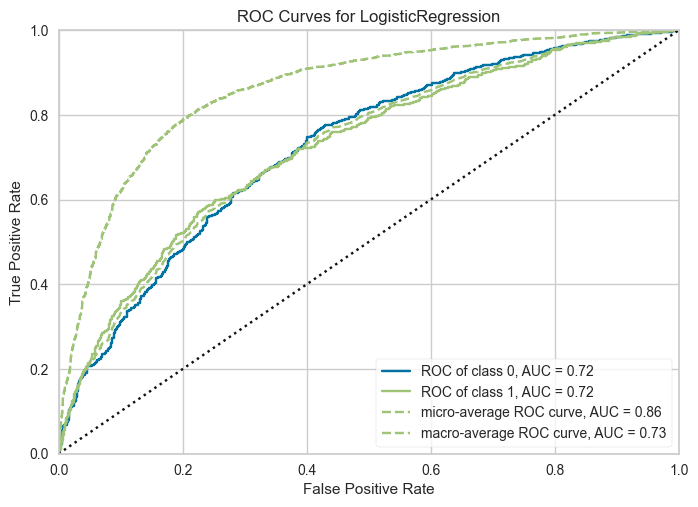

In [7]:
plot_model(lr_tuned, plot='auc')

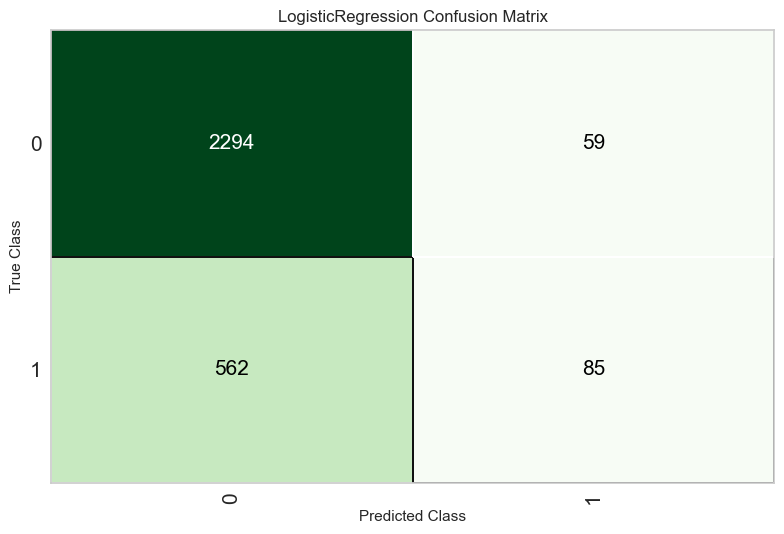

In [8]:
plot_model(lr_tuned, plot='confusion_matrix')

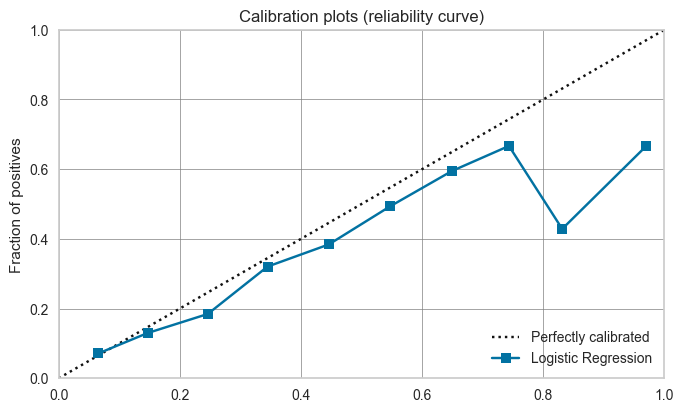

In [9]:
plot_model(lr_tuned, plot='calibration')

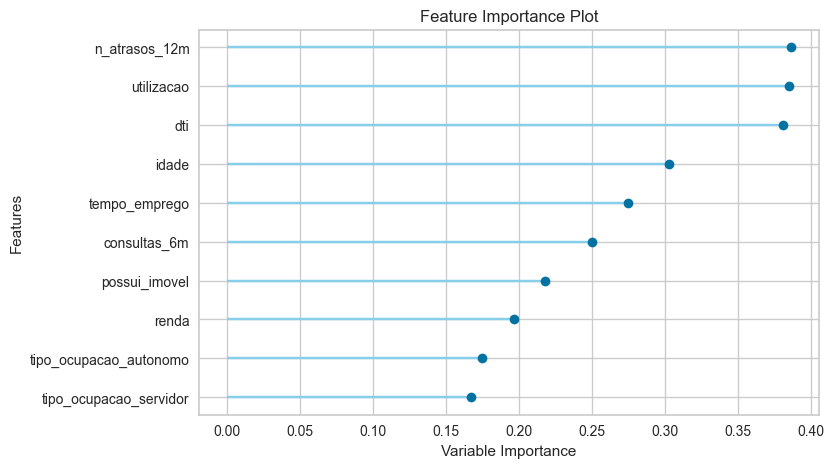

In [10]:
plot_model(lr_tuned, plot='feature')

## 6. Métricas de crédito no holdout: AUC, Gini, KS
`raw_score=True` devolve `prediction_score_1` = P(default), que é o que interessa (o `prediction_score` padrão é a prob. da classe predita).

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

pred = predict_model(lr_tuned, raw_score=True)
y = pred['default'].astype(int)
p = pred['prediction_score_1']

auc  = roc_auc_score(y, p)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y, p)
ks   = (tpr - fpr).max()

print(f"AUC  = {auc:.4f}")
print(f"Gini = {gini:.4f}")
print(f"KS   = {ks:.4f}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7930,0.7246,0.1314,0.5903,0.2149,0.1480,0.2045


AUC  = 0.7246
Gini = 0.4492
KS   = 0.3472


## 7. Tabela de decis (ordenação e concentração de default)

In [12]:
tab = pred[['default', 'prediction_score_1']].copy()
tab['decil'] = pd.qcut(tab['prediction_score_1'], 10, labels=False, duplicates='drop') + 1
tab['decil'] = tab['decil'].max() + 1 - tab['decil']   # 1 = maior risco

decis = (tab.groupby('decil')
            .agg(n=('default', 'size'),
                 defaults=('default', 'sum'),
                 pd_media=('prediction_score_1', 'mean'),
                 taxa_default=('default', 'mean'))
            .reset_index())
decis['pct_defaults_acum'] = decis['defaults'].cumsum() / decis['defaults'].sum()
decis.style.format({'pd_media': '{:.2%}', 'taxa_default': '{:.2%}', 'pct_defaults_acum': '{:.1%}'})

,decil,n,defaults,pd_media,taxa_default,pct_defaults_acum
0,1,300,161,52.18%,53.67%,24.9%
1,2,300,108,36.78%,36.00%,41.6%
2,3,300,100,29.38%,33.33%,57.0%
3,4,300,58,24.46%,19.33%,66.0%
4,5,300,55,20.22%,18.33%,74.5%
5,6,300,49,16.89%,16.33%,82.1%
6,7,299,36,13.78%,12.04%,87.6%
7,8,301,34,11.10%,11.30%,92.9%
8,9,299,30,8.55%,10.03%,97.5%
9,10,301,16,5.08%,5.32%,100.0%


## 8. Coeficientes e odds ratios
Como as numéricas foram padronizadas, o coeficiente lê-se como efeito de +1 desvio-padrão. Compare os sinais com o logit gerador da seção 1.

In [13]:
X_cols = get_config('X_train_transformed').columns
coefs = pd.DataFrame({
    'variavel': X_cols,
    'coef': lr_tuned.coef_[0],
})
coefs['odds_ratio'] = np.exp(coefs['coef'])
coefs = coefs.sort_values('coef', key=abs, ascending=False).reset_index(drop=True)
print(f"Intercepto: {lr_tuned.intercept_[0]:.4f}")
coefs

Intercepto: -1.4946


,variavel,coef,odds_ratio
0,n_atrasos_12m,0.386141,1.471292
1,utilizacao,0.384466,1.468829
2,dti,0.380744,1.463372
3,idade,-0.302668,0.738844
4,tempo_emprego,-0.274793,0.759729
5,consultas_6m,0.250035,1.284070
6,possui_imovel,-0.217486,0.804539
7,renda,-0.196301,0.821765
8,tipo_ocupacao_autonomo,0.174596,1.190765
9,tipo_ocupacao_servidor,-0.166931,0.846258


## 9. Finalizar (retreina em 100% da base), salvar e recarregar

In [14]:
lr_final = finalize_model(lr_tuned)
save_model(lr_final, 'modelo_lr_credito')   # gera modelo_lr_credito.pkl com todo o pipeline

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['idade', 'renda', 'tempo_emprego',
                                              'utilizacao', 'n_atrasos_12m',
                                              'dti', 'consultas_6m',
                                              'possui_imovel'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('catego...
                  TransformerWrapper(exclude=None, inclu

In [15]:
modelo = load_model('modelo_lr_credito')

novos = pd.DataFrame([
    {'idade': 32, 'renda': 2800, 'tempo_emprego': 1.5, 'utilizacao': 0.85, 'n_atrasos_12m': 2,
     'dti': 0.45, 'consultas_6m': 4, 'tipo_ocupacao': 'autonomo', 'possui_imovel': 0},
    {'idade': 55, 'renda': 9000, 'tempo_emprego': 20, 'utilizacao': 0.15, 'n_atrasos_12m': 0,
     'dti': 0.10, 'consultas_6m': 0, 'tipo_ocupacao': 'servidor', 'possui_imovel': 1},
])
predict_model(modelo, data=novos, raw_score=True)[['tipo_ocupacao', 'prediction_label', 'prediction_score_1']]

Transformation Pipeline and Model Successfully Loaded


,tipo_ocupacao,prediction_label,prediction_score_1
0,autonomo,1,0.9315
1,servidor,0,0.0066


## Próximos passos (opcionais)
- `compare_models()` para ver LR contra GBM/RF/etc. no mesmo `setup`.
- `plot_model(lr_tuned, plot='threshold')` para escolher o corte de aprovação.
- `interpret_model(lr_tuned)` (requer `pip install "pycaret[analysis]"`, usa SHAP).
- Trocar a base simulada por `from pycaret.datasets import get_data; df = get_data('credit')` (UCI Taiwan, target `default`).

In [16]:
# ── A) compare_models: LR contra os demais no mesmo setup ──────────────────
best = compare_models(sort='AUC', n_select=1)
pull()   # tabela completa de métricas de todos os modelos

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7956,0.7237,0.1509,0.6096,0.2414,0.1702,0.2267,0.0600
ridge,Ridge Classifier,0.7944,0.7237,0.0907,0.6791,0.1595,0.1147,0.1933,0.0600
lda,Linear Discriminant Analysis,0.7959,0.7237,0.1641,0.6016,0.2572,0.1815,0.2338,0.0540
gbc,Gradient Boosting Classifier,0.7910,0.7090,0.1251,0.5742,0.2053,0.1387,0.1932,0.4860
ada,Ada Boost Classifier,0.7893,0.7074,0.1727,0.5428,0.2606,0.1745,0.2143,0.2220
nb,Naive Bayes,0.7799,0.6935,0.2468,0.4813,0.3257,0.2103,0.2273,0.0640
rf,Random Forest Classifier,0.7877,0.6846,0.1072,0.5383,0.1784,0.1156,0.1661,0.5040
qda,Quadratic Discriminant Analysis,0.7193,0.6750,0.3548,0.3788,0.3434,0.1742,0.1846,0.0640
et,Extra Trees Classifier,0.7811,0.6674,0.1178,0.4681,0.1877,0.1115,0.1472,0.3280
svm,SVM - Linear Kernel,0.7861,0.6644,0.0212,0.4756,0.0384,0.0266,0.0642,0.0760


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7956,0.7237,0.1509,0.6096,0.2414,0.1702,0.2267,0.060
ridge,Ridge Classifier,0.7944,0.7237,0.0907,0.6791,0.1595,0.1147,0.1933,0.060
lda,Linear Discriminant Analysis,0.7959,0.7237,0.1641,0.6016,0.2572,0.1815,0.2338,0.054
gbc,Gradient Boosting Classifier,0.7910,0.7090,0.1251,0.5742,0.2053,0.1387,0.1932,0.486
ada,Ada Boost Classifier,0.7893,0.7074,0.1727,0.5428,0.2606,0.1745,0.2143,0.222
nb,Naive Bayes,0.7799,0.6935,0.2468,0.4813,0.3257,0.2103,0.2273,0.064
rf,Random Forest Classifier,0.7877,0.6846,0.1072,0.5383,0.1784,0.1156,0.1661,0.504
qda,Quadratic Discriminant Analysis,0.7193,0.6750,0.3548,0.3788,0.3434,0.1742,0.1846,0.064
et,Extra Trees Classifier,0.7811,0.6674,0.1178,0.4681,0.1877,0.1115,0.1472,0.328
svm,SVM - Linear Kernel,0.7861,0.6644,0.0212,0.4756,0.0384,0.0266,0.0642,0.076


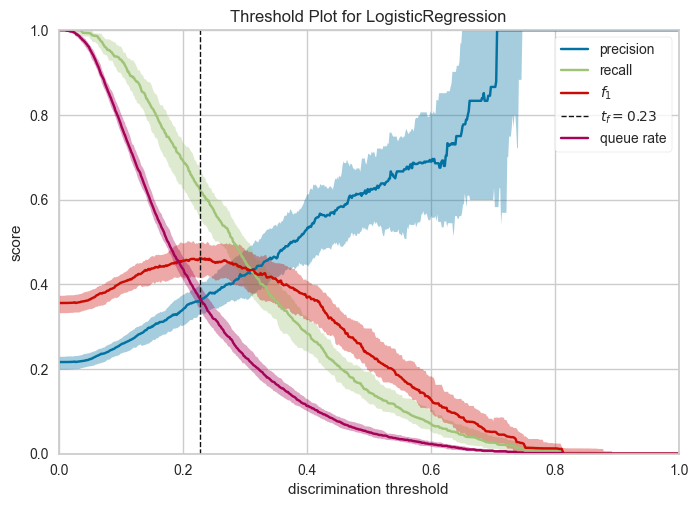

Threshold: 0.375. F1: 0.3872
Threshold: 0.125. F1: 0.4217
Threshold: 0.5. F1: 0.2414
Threshold: 0.25. F1: 0.4544
Threshold: 0.625. F1: 0.1084
Threshold: 0.75. F1: 0.0209
Threshold: 0.875. F1: 0.0013
Threshold: 0.0. F1: 0.3551
Threshold: 0.25. F1: 0.4544
Threshold: 0.2500000149011612. F1: 0.4544
Threshold: 0.21875. F1: 0.4577
Threshold: 0.09375. F1: 0.398
Threshold: 0.3125. F1: 0.4278
Threshold: 0.1875. F1: 0.4525
Threshold: 0.34375. F1: 0.4133
Threshold: 0.4375. F1: 0.3192
Threshold: 0.46875. F1: 0.2776
Threshold: 0.5625. F1: 0.1763
Threshold: 0.59375. F1: 0.1442
Threshold: 0.6875. F1: 0.0586
Threshold: 0.71875. F1: 0.0349
Threshold: 0.8125. F1: 0.0092
Threshold: 0.84375. F1: 0.0053
Threshold: 0.9375. F1: 0.0
Threshold: 0.0625. F1: 0.3746
Threshold: 0.96875. F1: 0.0
Threshold: 0.21875. F1: 0.4577
Threshold: 0.2187500149011612. F1: 0.4577
Threshold: 0.484375. F1: 0.2604
Threshold: 0.53125. F1: 0.2068
Threshold: 0.546875. F1: 0.1916
Threshold: 0.609375. F1: 0.1261
Threshold: 0.671875. F1

Threshold ótimo (F1): 0.2344
Threshold ótimo por custo: 0.09  (aprovaria 16.4% da carteira)


In [17]:
# ── B) Escolha do corte de aprovação ────────────────────────────────────────
plot_model(lr_tuned, plot='threshold')

# corte ótimo por métrica (F1, Precision, Recall, ou custo customizado)
lr_thr = optimize_threshold(lr_tuned, optimize='F1')
thr = lr_thr.probability_threshold
print(f"Threshold ótimo (F1): {thr:.4f}")

# corte por custo de negócio: custo FN (default aprovado) vs FP (bom recusado)
from sklearn.metrics import confusion_matrix
custo_fn, custo_fp = 10, 1
grid = np.arange(0.02, 0.60, 0.01)
custos = []
for t in grid:
    tn, fp, fn, tp = confusion_matrix(y, (p >= t).astype(int)).ravel()
    custos.append(fn * custo_fn + fp * custo_fp)
thr_custo = grid[int(np.argmin(custos))]
print(f"Threshold ótimo por custo: {thr_custo:.2f}  (aprovaria {(p < thr_custo).mean():.1%} da carteira)")

In [18]:
import sys
!{sys.executable} -m pip install shap

In [19]:
import scipy, shap; print(scipy.__version__, shap.__version__)

1.11.4 0.44.1


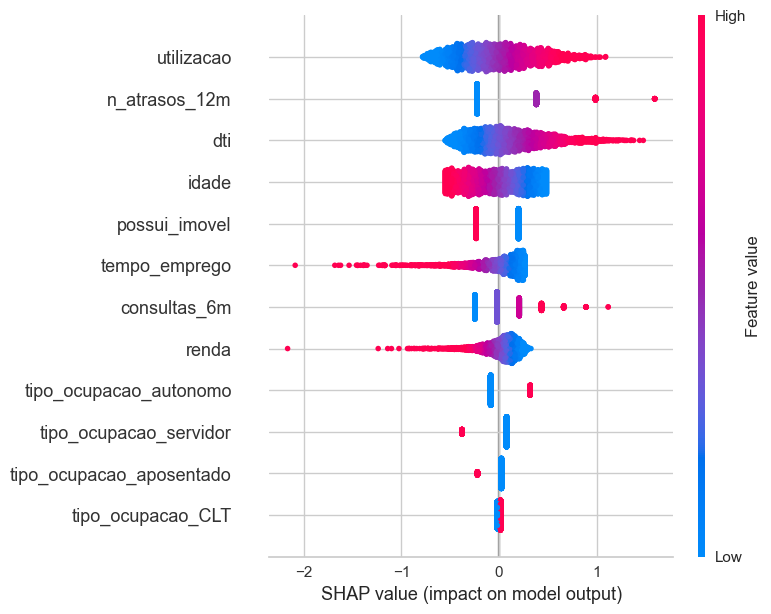

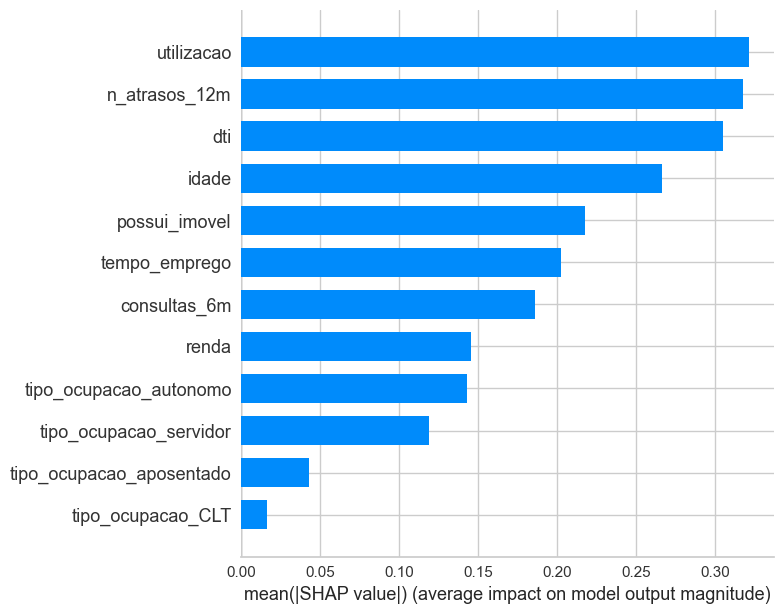

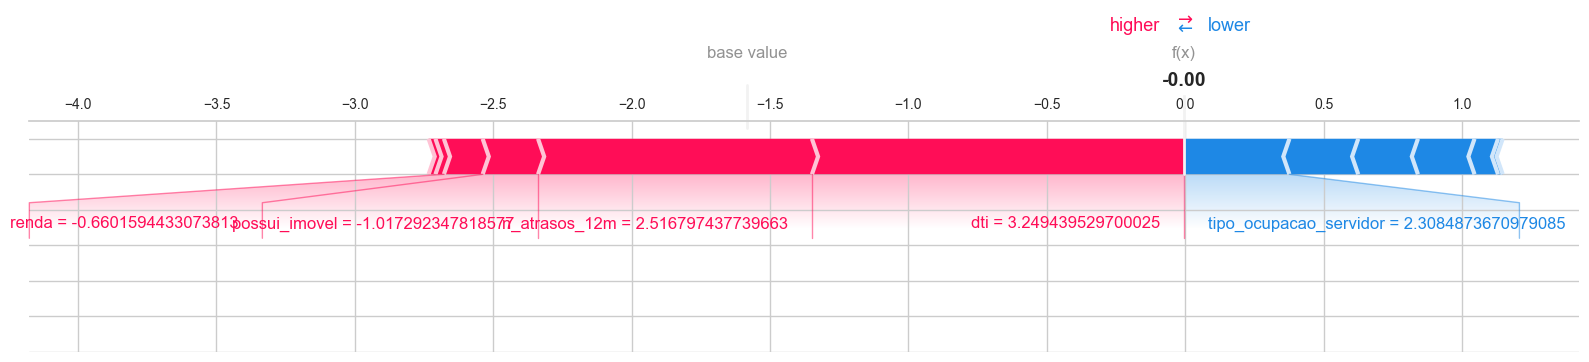

In [20]:
# ── C) SHAP para LR (interpret_model do PyCaret só aceita modelos de árvore) ─
# import shap
X_tr = get_config('X_train_transformed')
X_te = get_config('X_test_transformed')

explainer = shap.LinearExplainer(lr_tuned, X_tr)
shap_vals = explainer.shap_values(X_te)

shap.summary_plot(shap_vals, X_te)                        # importância + direção
shap.summary_plot(shap_vals, X_te, plot_type='bar')       # importância média
shap.force_plot(explainer.expected_value, shap_vals[0], X_te.iloc[0], matplotlib=True)  # um cliente

In [21]:
# ── D) Base real: UCI Taiwan credit default (30k linhas, target 'default') ──
from pycaret.datasets import get_data
df_real = get_data('credit')
print(df_real.shape, f"taxa de default: {df_real['default'].mean():.2%}")

exp_real = setup(data=df_real, target='default', train_size=0.70, session_id=42,
                 normalize=True, fold=5, verbose=False)
lr_real = tune_model(create_model('lr'), optimize='AUC', n_iter=20)

pred_r = predict_model(lr_real, raw_score=True)
y_r, p_r = pred_r['default'].astype(int), pred_r['prediction_score_1']
auc_r = roc_auc_score(y_r, p_r)
fpr_r, tpr_r, _ = roc_curve(y_r, p_r)
print(f"AUC={auc_r:.4f}  Gini={2*auc_r-1:.4f}  KS={(tpr_r-fpr_r).max():.4f}")

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,90000,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
2,50000,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
3,50000,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
4,50000,1,1,2,37,0,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0


(24000, 24) taxa de default: 22.11%


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8071,0.7040,0.2197,0.7026,0.3347,0.2565,0.3163
1,0.8027,0.7301,0.2059,0.6770,0.3158,0.2371,0.2950
2,0.8062,0.7294,0.2288,0.6855,0.3431,0.2613,0.3159
3,0.8086,0.7231,0.2275,0.7101,0.3445,0.2658,0.3253
4,0.8167,0.7187,0.2503,0.7592,0.3765,0.2997,0.3636
Mean,0.8083,0.7211,0.2264,0.7069,0.3429,0.2641,0.3232
Std,0.0046,0.0095,0.0145,0.0287,0.0197,0.0203,0.0225


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6824,0.7045,0.6253,0.3703,0.4652,0.2598,0.2779
1,0.6952,0.7321,0.6608,0.3888,0.4895,0.2925,0.3135
2,0.6842,0.7304,0.6689,0.3788,0.4837,0.2806,0.3041
3,0.6896,0.7241,0.6245,0.3779,0.4708,0.2696,0.2866
4,0.6771,0.7190,0.6380,0.3674,0.4663,0.2581,0.2783
Mean,0.6857,0.7220,0.6435,0.3766,0.4751,0.2721,0.2921
Std,0.0062,0.0099,0.0183,0.0075,0.0098,0.0130,0.0143


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.6804,0.7195,0.6307,0.3695,0.4660,0.2595,0.2784


AUC=0.7195  Gini=0.4390  KS=0.3701


FACTOR=180.344  OFFSET=240.8  PDO implícito=125.0
count    3000.0
mean      505.7
std       156.8
min       100.0
25%       399.0
50%       508.5
75%       616.2
max       900.0
Name: score, dtype: float64


,n,defaults,taxa_default,pct_carteira
score,,,,
"(99.999, 200.0]",89,56,62.92%,3.0%
"(200.0, 300.0]",214,106,49.53%,7.1%
"(300.0, 400.0]",455,162,35.60%,15.2%
"(400.0, 500.0]",673,144,21.40%,22.4%
"(500.0, 600.0]",702,106,15.10%,23.4%
"(600.0, 700.0]",553,55,9.95%,18.4%
"(700.0, 800.0]",228,15,6.58%,7.6%
"(800.0, 900.0]",86,3,3.49%,2.9%


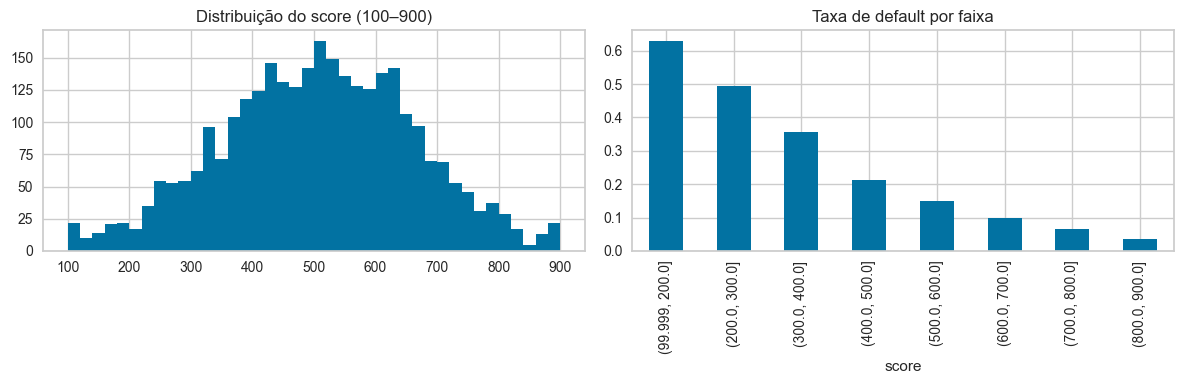

In [22]:
# ── E) Normalização do score para a escala 100–900 ──────────────────────────
# Escala padrão de crédito: score = OFFSET + FACTOR * ln(odds_bom); PDO = pontos para dobrar as odds.
import matplotlib.pyplot as plt

PDO, BASE_SCORE, BASE_ODDS = 40, 600, 20        # a cada 40 pts as odds de bom dobram; 600 pts ⇔ odds 20:1
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

CALIBRAR_FAIXA_CHEIA = True   # True: reajusta FACTOR/OFFSET para os percentis 0,5% e 99,5% caírem em 100 e 900
if CALIBRAR_FAIXA_CHEIA:
    p_best, p_worst = np.quantile(p, [0.005, 0.995])
    lo_best, lo_worst = np.log((1 - p_best) / p_best), np.log((1 - p_worst) / p_worst)
    FACTOR = (900 - 100) / (lo_best - lo_worst)
    OFFSET = 100 - FACTOR * lo_worst
    PDO = FACTOR * np.log(2)

print(f"FACTOR={FACTOR:.3f}  OFFSET={OFFSET:.1f}  PDO implícito={PDO:.1f}")

def prob_para_score(p, lo=100, hi=900, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    odds_bom = (1 - p) / p
    return np.clip(OFFSET + FACTOR * np.log(odds_bom), lo, hi).round(0).astype(int)

def score_para_prob(s):
    return 1 / (1 + np.exp((np.asarray(s, dtype=float) - OFFSET) / FACTOR))

pred['score'] = prob_para_score(p)
print(pred['score'].describe().round(1))

faixas = pd.cut(pred['score'], bins=range(100, 901, 100), include_lowest=True)
tab_faixas = (pred.groupby(faixas, observed=True)
                  .agg(n=('default', 'size'), defaults=('default', 'sum'), taxa_default=('default', 'mean'))
                  .assign(pct_carteira=lambda t: t['n'] / t['n'].sum()))
display(tab_faixas.style.format({'taxa_default': '{:.2%}', 'pct_carteira': '{:.1%}'}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pred['score'].hist(bins=40, ax=ax[0]); ax[0].set_title('Distribuição do score (100–900)')
pred.groupby(faixas, observed=True)['default'].mean().plot(kind='bar', ax=ax[1]); ax[1].set_title('Taxa de default por faixa')
plt.tight_layout(); plt.show()

In [23]:
# ── F) Scorecard com variáveis categorizadas (WoE → LR → pontos por faixa) ──
# Usa FACTOR/OFFSET da célula E. Modelo próprio (sklearn) para a tabela ser 100% transparente.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_all, y_all = df.drop(columns='default'), df['default']
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.30, random_state=42, stratify=y_all)

# 1) Regras de categorização: quantis para contínuas, cortes manuais para contagens/flags
vars_quantil = ['idade', 'renda', 'tempo_emprego', 'utilizacao', 'dti']
bins_manual = {
    'n_atrasos_12m': [-np.inf, 0, 1, np.inf],     # 0 | 1 | 2+
    'consultas_6m':  [-np.inf, 0, 2, np.inf],     # 0 | 1–2 | 3+
    'possui_imovel': [-np.inf, 0, np.inf],        # não | sim
}
vars_cat = ['tipo_ocupacao']

regras = {}
for v in vars_quantil:
    edges = np.unique(np.quantile(X_tr_raw[v], [0, .2, .4, .6, .8, 1]))
    edges[0], edges[-1] = -np.inf, np.inf
    regras[v] = edges
regras.update(bins_manual)

def categorizar(X):
    out = pd.DataFrame(index=X.index)
    for v, edges in regras.items():
        out[v] = pd.cut(X[v], bins=edges, include_lowest=True)
    for v in vars_cat:
        out[v] = X[v].astype('category')
    return out

C_tr, C_te = categorizar(X_tr_raw), categorizar(X_te_raw)

# 2) WoE e IV por faixa (WoE = ln(%bons/%maus): positivo = faixa mais segura)
def tabela_woe(cat, y, eps=0.5):
    y = np.asarray(y); tot_b, tot_m = (y == 0).sum(), (y == 1).sum()
    linhas = []
    for v in cat.columns:
        ct = pd.crosstab(cat[v], y)
        for faixa, row in ct.iterrows():
            b, m = row.get(0, 0), row.get(1, 0)
            woe = np.log(((b + eps) / tot_b) / ((m + eps) / tot_m))
            iv  = ((b + eps) / tot_b - (m + eps) / tot_m) * woe
            linhas.append(dict(variavel=v, faixa=str(faixa), n=b + m, defaults=m,
                               taxa_default=m / (b + m), woe=woe, iv=iv))
    return pd.DataFrame(linhas)

woe_tab = tabela_woe(C_tr, y_tr)
iv_por_var = woe_tab.groupby('variavel')['iv'].sum().sort_values(ascending=False)
print("Information Value por variável:\n", iv_por_var.round(3))

woe_map = {v: dict(zip(g['faixa'], g['woe'])) for v, g in woe_tab.groupby('variavel')}
def para_woe(cat):
    return pd.DataFrame({v: cat[v].astype(str).map(woe_map[v]).astype(float) for v in cat.columns},
                        index=cat.index).fillna(0.0)          # faixa não vista → WoE neutro

W_tr, W_te = para_woe(C_tr), para_woe(C_te)

# 3) LR sobre WoE (sem regularização) e conversão para pontos
lr_sc = LogisticRegression(C=1e6, max_iter=1000).fit(W_tr, y_tr)
beta  = pd.Series(lr_sc.coef_[0], index=W_tr.columns)
alpha = lr_sc.intercept_[0]
n_vars = len(beta)

woe_tab['pontos'] = (woe_tab.apply(lambda r: -FACTOR * beta[r['variavel']] * r['woe']
                                             + (OFFSET - FACTOR * alpha) / n_vars, axis=1)
                            .round(0).astype(int))

scorecard = woe_tab[['variavel', 'faixa', 'n', 'taxa_default', 'woe', 'pontos']]
display(scorecard.style.format({'taxa_default': '{:.2%}', 'woe': '{:.3f}'})
                        .background_gradient(subset=['pontos'], cmap='RdYlGn'))

# 4) Função de escoragem pelo scorecard
pts_map = {v: dict(zip(g['faixa'], g['pontos'])) for v, g in woe_tab.groupby('variavel')}
pts_neutro = {v: int(round(np.mean(list(m.values())))) for v, m in pts_map.items()}

def score_scorecard(X):
    cat = categorizar(X)
    pts = pd.DataFrame({v: cat[v].astype(str).map(pts_map[v]).fillna(pts_neutro[v]).astype(int)
                        for v in cat.columns}, index=X.index)
    pts['score'] = pts.sum(axis=1).clip(100, 900)
    return pts

# 5) Validação no holdout: scorecard vs. LR do PyCaret (mesmo conjunto de teste)
sc_te = score_scorecard(X_te_raw)
p_lr_te = exp.predict_model(lr_tuned, data=X_te_raw, raw_score=True, verbose=False)['prediction_score_1'].values

def metricas(y, s, nome, invertido=False):
    s = -np.asarray(s) if invertido else np.asarray(s)      # score alto = risco baixo → inverte p/ AUC
    auc = roc_auc_score(y, s); fpr_, tpr_, _ = roc_curve(y, s)
    print(f"{nome:<22} AUC={auc:.4f}  Gini={2*auc-1:.4f}  KS={(tpr_-fpr_).max():.4f}")

metricas(y_te, p_lr_te,        'LR PyCaret (prob)')
metricas(y_te, sc_te['score'], 'Scorecard (pontos)', invertido=True)

# 6) Leitura de um cliente: pontos por variável
cliente = X_te_raw.iloc[[0]]
display(pd.concat([cliente.T.rename(columns={cliente.index[0]: 'valor'}),
                   score_scorecard(cliente).T.rename(columns={cliente.index[0]: 'pontos'})], axis=1))

Information Value por variável:
 variavel
n_atrasos_12m    0.126
utilizacao       0.111
dti              0.107
idade            0.065
tipo_ocupacao    0.059
consultas_6m     0.053
tempo_emprego    0.045
possui_imovel    0.040
renda            0.030
Name: iv, dtype: float64


,variavel,faixa,n,taxa_default,woe,pontos
0,idade,"(-inf, 30.0]",1417,28.51%,-0.371,-24
1,idade,"(30.0, 40.0]",1424,23.31%,-0.100,32
2,idade,"(40.0, 49.0]",1376,21.73%,-0.010,51
3,idade,"(49.0, 60.0]",1521,17.95%,0.228,100
4,idade,"(60.0, inf]",1262,16.09%,0.360,127
5,renda,"(-inf, 2390.8]",1400,25.50%,-0.219,9
6,renda,"(2390.8, 3205.6]",1400,23.93%,-0.134,26
7,renda,"(3205.6, 4094.0]",1401,20.70%,0.052,63
8,renda,"(4094.0, 5547.0]",1400,20.64%,0.055,64
9,renda,"(5547.0, inf]",1399,17.16%,0.283,110


LR PyCaret (prob)      AUC=0.7246  Gini=0.4492  KS=0.3472
Scorecard (pontos)     AUC=0.7208  Gini=0.4415  KS=0.3340


,valor,pontos
idade,53,100
renda,2663.0,26
tempo_emprego,8.9,138
utilizacao,0.43,60
n_atrasos_12m,2,-124
dti,0.812,-40
consultas_6m,0,109
tipo_ocupacao,servidor,144
possui_imovel,0,14
score,NaN,427


In [24]:
# ── G) Safra como controle: OOS in-time vs OOT ──────────────────────────────
rng2 = np.random.default_rng(7)
safras = pd.period_range('2023-01', '2024-12', freq='M').strftime('%Y%m')
df['safra'] = rng2.choice(safras, size=len(df))
# base simulada é estacionária por construção; para ver drift nos testes, descomente:
# m = df['safra'] >= '202407'; df.loc[m, 'utilizacao'] = (df.loc[m, 'utilizacao'] * 1.25).clip(upper=1)

N_OOT = 6
safras_oot = sorted(df['safra'].unique())[-N_OOT:]
df_dev = df[~df['safra'].isin(safras_oot)].copy()
df_oot = df[df['safra'].isin(safras_oot)].copy()
df_dev_tr, df_oos = train_test_split(df_dev, test_size=0.20, random_state=42, stratify=df_dev['default'])
print(f"dev_train={len(df_dev_tr)}  OOS={len(df_oos)}  OOT={len(df_oot)}  safras OOT={safras_oot}")

exp_oot = setup(
    data=df_dev_tr, test_data=df_oot, target='default', ignore_features=['safra'],
    categorical_features=['tipo_ocupacao'],
    numeric_features=['idade', 'renda', 'tempo_emprego', 'utilizacao', 'n_atrasos_12m', 'dti', 'consultas_6m', 'possui_imovel'],
    normalize=True, fold=5, session_id=42, verbose=False,
)
lr_oot = tune_model(create_model('lr'), optimize='AUC', n_iter=20)

def metr(y, s):
    auc = roc_auc_score(y, s); fpr_, tpr_, _ = roc_curve(y, s)
    return dict(AUC=auc, Gini=2 * auc - 1, KS=(tpr_ - fpr_).max())

def prob(model, data):
    return exp_oot.predict_model(model, data=data, raw_score=True, verbose=False)['prediction_score_1'].values

p_oos, p_oot = prob(lr_oot, df_oos), prob(lr_oot, df_oot)
display(pd.DataFrame({'OOS (in-time)': metr(df_oos['default'], p_oos),
                      'OOT':           metr(df_oot['default'], p_oot)}).T.round(4))

dev_train=5986  OOS=1497  OOT=2517  safras OOT=['202407', '202408', '202409', '202410', '202411', '202412']


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8038,0.7142,0.1595,0.6833,0.2587,0.1932,0.2622
1,0.7970,0.7375,0.1641,0.5915,0.2569,0.1808,0.2313
2,0.8079,0.7453,0.1523,0.7500,0.2532,0.1951,0.2786
3,0.7953,0.6973,0.1562,0.5797,0.2462,0.1709,0.2207
4,0.7928,0.7258,0.1245,0.5818,0.2051,0.1400,0.1962
Mean,0.7994,0.7240,0.1513,0.6373,0.2440,0.1760,0.2378
Std,0.0056,0.0170,0.0140,0.0683,0.0199,0.0200,0.0294


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6494,0.7151,0.6381,0.3340,0.4385,0.2184,0.2426
1,0.6658,0.7372,0.6641,0.3512,0.4595,0.2495,0.2760
2,0.6834,0.7456,0.6797,0.3694,0.4787,0.2788,0.3056
3,0.6541,0.6969,0.6367,0.3368,0.4405,0.2232,0.2470
4,0.6633,0.7255,0.6498,0.3479,0.4532,0.2409,0.2654
Mean,0.6632,0.7241,0.6537,0.3479,0.4541,0.2422,0.2673
Std,0.0117,0.0171,0.0163,0.0126,0.0146,0.0216,0.0227


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,AUC,Gini,KS
OOS (in-time),0.7384,0.4768,0.3858
OOT,0.7155,0.4310,0.3264


,amostra,n,taxa_default,pd_media,AUC,Gini,KS,PSI_score
safra,,,,,,,,
202301,OOS,73,24.66%,48.60%,0.692,0.385,0.341,0.046
202302,OOS,77,14.29%,42.36%,0.791,0.581,0.500,0.255
202303,OOS,78,26.92%,44.68%,0.772,0.544,0.521,0.026
202304,OOS,86,23.26%,50.34%,0.747,0.494,0.523,0.154
202305,OOS,94,18.09%,48.04%,0.734,0.468,0.367,0.094
202306,OOS,89,17.98%,44.53%,0.603,0.206,0.235,0.037
202307,OOS,100,23.00%,43.84%,0.788,0.577,0.457,0.059
202308,OOS,92,20.65%,46.95%,0.828,0.655,0.548,0.026
202309,OOS,69,20.29%,50.04%,0.678,0.356,0.369,0.134


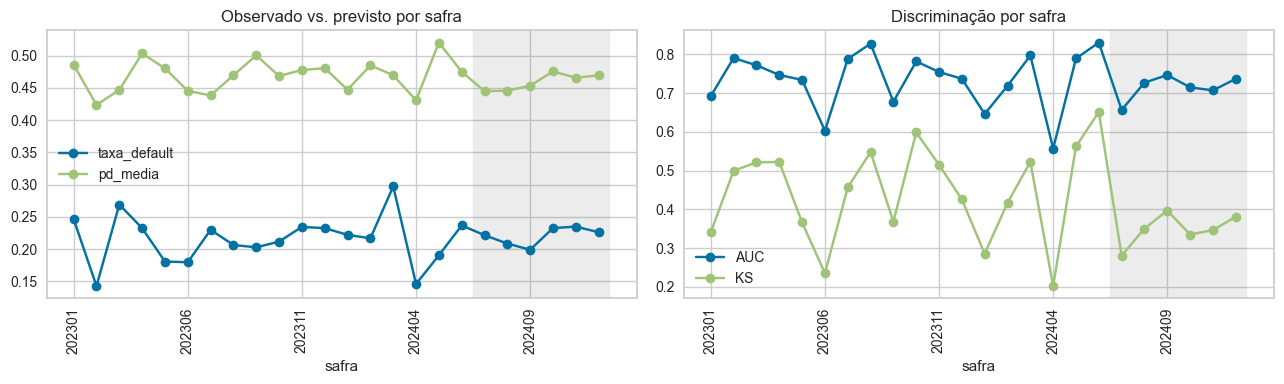

In [25]:
# ── G1) Taxa de default, discriminação e PSI do score por safra ─────────────
df_val = pd.concat([df_oos.assign(amostra='OOS', p=p_oos), df_oot.assign(amostra='OOT', p=p_oot)])
df_val['score'] = prob_para_score(df_val['p'])

def psi(ref, cur, bins):
    r = np.histogram(ref, bins)[0] / len(ref); c = np.histogram(cur, bins)[0] / len(cur)
    r, c = np.clip(r, 1e-6, None), np.clip(c, 1e-6, None)
    return float(((c - r) * np.log(c / r)).sum())

ref_score = df_val.loc[df_val['amostra'] == 'OOS', 'score']
bins_score = np.quantile(ref_score, np.linspace(0, 1, 11)); bins_score[0], bins_score[-1] = -np.inf, np.inf

por_safra = (df_val.groupby('safra')
                   .apply(lambda g: pd.Series({'amostra': g['amostra'].iloc[0], 'n': len(g),
                                               'taxa_default': g['default'].mean(), 'pd_media': g['p'].mean(),
                                               **metr(g['default'], g['p']),
                                               'PSI_score': psi(ref_score, g['score'], bins_score)})))
display(por_safra.style.format({'taxa_default': '{:.2%}', 'pd_media': '{:.2%}', 'AUC': '{:.3f}',
                                'Gini': '{:.3f}', 'KS': '{:.3f}', 'PSI_score': '{:.3f}'})
                       .background_gradient(subset=['PSI_score'], cmap='Reds', vmin=0, vmax=0.25))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
por_safra[['taxa_default', 'pd_media']].plot(ax=ax[0], marker='o'); ax[0].set_title('Observado vs. previsto por safra')
por_safra[['AUC', 'KS']].plot(ax=ax[1], marker='o'); ax[1].set_title('Discriminação por safra')
for a in ax:
    a.axvspan(list(por_safra.index).index(safras_oot[0]) - 0.5, len(por_safra) - 0.5, alpha=0.15, color='grey')
    a.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

In [26]:
# ── G2) Ordenação do WoE por faixa: dev vs OOT (+ CSI por variável) ─────────
# Reaproveita categorizar()/tabela_woe() da célula F (faixas fixadas em X_tr_raw).
from scipy.stats import spearmanr

def woe_e_dist(dfx):
    cat = categorizar(dfx.drop(columns=['default', 'safra', 'p', 'score', 'amostra'], errors='ignore'))
    w = tabela_woe(cat, dfx['default']).set_index(['variavel', 'faixa'])
    d = pd.concat({v: cat[v].astype(str).value_counts(normalize=True) for v in cat.columns}, names=['variavel', 'faixa'])
    return w['woe'], w['taxa_default'], d

woe_dev, td_dev, dist_dev = woe_e_dist(df_dev)
woe_oot, td_oot, dist_oot = woe_e_dist(df_oot)

comp = pd.concat([td_dev.rename('taxa_dev'), td_oot.rename('taxa_oot'),
                  woe_dev.rename('woe_dev'), woe_oot.rename('woe_oot'),
                  dist_dev.rename('pct_dev'), dist_oot.rename('pct_oot')], axis=1)
comp['inversao_sinal'] = (comp['woe_dev'] * comp['woe_oot']) < 0
display(comp.style.format({'taxa_dev': '{:.2%}', 'taxa_oot': '{:.2%}', 'woe_dev': '{:.3f}', 'woe_oot': '{:.3f}',
                           'pct_dev': '{:.1%}', 'pct_oot': '{:.1%}'}))

resumo = []
for v, g in comp.groupby(level='variavel'):
    r, c = np.clip(g['pct_dev'], 1e-6, None), np.clip(g['pct_oot'], 1e-6, None)
    resumo.append(dict(variavel=v,
                       rho_ordenacao=spearmanr(g['woe_dev'], g['woe_oot']).correlation if len(g) > 2 else np.nan,
                       faixas_com_inversao=int(g['inversao_sinal'].sum()),
                       CSI=float(((c - r) * np.log(c / r)).sum())))
resumo = pd.DataFrame(resumo).set_index('variavel').sort_values('CSI', ascending=False)
display(resumo.style.format({'rho_ordenacao': '{:.2f}', 'CSI': '{:.4f}'})
                    .background_gradient(subset=['CSI'], cmap='Reds', vmin=0, vmax=0.25))
# Leitura: rho≈1 → ordenação das faixas mantida; inversão>0 → faixa mudou de "boa" p/ "ruim"; CSI>0.10 atenção, >0.25 quebra.

,rho_ordenacao,faixas_com_inversao,CSI
variavel,,,
tempo_emprego,0.70,0,0.0046
idade,0.90,0,0.0041
dti,0.90,1,0.0020
tipo_ocupacao,1.00,1,0.0019
renda,1.00,1,0.0013
utilizacao,1.00,1,0.0012
n_atrasos_12m,1.00,0,0.0012
consultas_6m,1.00,0,0.0005
possui_imovel,nan,0,0.0001


In [27]:
# ── G3) Estabilidade dos betas em janelas de tempo (LR sobre WoE) ───────────
# Reaproveita para_woe() da célula F (WoE fixado no dev). Convenção: WoE=ln(bons/maus) → beta esperado < 0.
cat_all = categorizar(df.drop(columns=['default', 'safra']))
W_all = para_woe(cat_all)
trimestre = df['safra'].str[:4] + 'T' + ((df['safra'].str[4:].astype(int) - 1) // 3 + 1).astype(str)

betas = {}
for j, idx in df.groupby(trimestre).groups.items():
    m = LogisticRegression(C=1e6, max_iter=1000).fit(W_all.loc[idx], df.loc[idx, 'default'])
    betas[j] = m.coef_[0]
betas = pd.DataFrame(betas, index=W_all.columns).T
betas.loc['dev_completo'] = LogisticRegression(C=1e6, max_iter=1000).fit(W_all.loc[df_dev.index], df_dev['default']).coef_[0]

display(betas.style.format('{:.2f}').background_gradient(cmap='RdYlGn_r', axis=None))
print("Variáveis com beta > 0 em alguma janela (sinal contra a lógica):",
      list(betas.columns[(betas.drop(index='dev_completo') > 0).any()]))

,idade,renda,tempo_emprego,utilizacao,dti,n_atrasos_12m,consultas_6m,possui_imovel,tipo_ocupacao
2023T1,-1.10,-1.52,-1.59,-1.29,-1.13,-1.15,-0.51,-0.68,-1.71
2023T2,-1.02,-1.17,-0.69,-0.57,-0.84,-1.08,-1.29,-0.95,-0.98
2023T3,-0.81,-1.51,-0.61,-1.21,-1.32,-1.20,-1.86,-1.08,-0.98
2023T4,-1.62,-0.89,-1.43,-1.43,-1.35,-1.29,-1.42,-1.28,-1.21
2024T1,-1.01,-0.50,-1.38,-1.63,-1.34,-1.10,-0.59,-1.46,-0.87
2024T2,-1.07,-1.10,-1.05,-0.99,-1.03,-1.15,-1.33,-1.25,-1.18
2024T3,-0.90,-0.52,-1.04,-0.82,-1.35,-0.99,-1.31,-1.00,-1.01
2024T4,-1.06,-1.66,-1.50,-1.27,-1.31,-0.87,-0.89,-1.49,-0.82
dev_completo,-1.07,-1.10,-1.08,-1.16,-1.16,-1.14,-1.20,-1.12,-1.13


Variáveis com beta > 0 em alguma janela (sinal contra a lógica): []


In [28]:
# ── H) Refino recursivo do scorecard até atender restrições de estabilidade ─
# Depende de: df_dev, df_oot, df_oos (G), FACTOR/OFFSET/prob_para_score (E), metr (G).
# Ciclo: binar → diagnosticar cada variável → mesclar faixa ou descartar variável → refazer;
# só quando não há mais ação de faixa, testa os betas (dev + janelas de tempo) e descarta o pior.
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression

RESTR = dict(
    iv_min=0.02,         # variável fraca → descarta
    n_min_faixa=0.05,    # população mínima por faixa (fração do dev) → mescla
    monotonico=True,     # WoE monotônico nas numéricas → mescla par fora de ordem
    rho_min=0.80,        # Spearman(WoE dev, WoE OOT) → mescla par com maior discordância de rank
    csi_max=0.10,        # CSI dev vs OOT → mescla faixa que mais contribui; com 2 faixas → descarta
    beta_tol=0.0,        # beta (sobre WoE) acima disso = contra a lógica → descarta
    janela='S',          # 'S' semestre | 'T' trimestre | None (só dev) para o teste de betas
    max_iter=40,
)
NUM_Q   = ['idade', 'renda', 'tempo_emprego', 'utilizacao', 'dti']
NUM_MAN = {'n_atrasos_12m': [-np.inf, 0, 1, np.inf], 'consultas_6m': [-np.inf, 0, 2, np.inf], 'possui_imovel': [-np.inf, 0, np.inf]}
CATS    = ['tipo_ocupacao']

X_dev, y_dev = df_dev.drop(columns=['default', 'safra']), df_dev['default'].values
X_oot, y_oot = df_oot.drop(columns=['default', 'safra']), df_oot['default'].values
X_all, y_all = df.drop(columns=['default', 'safra']), df['default'].values

# ---------- binagem ----------
def spec_inicial(X, n_q=5):
    spec = {}
    for v in NUM_Q:
        e = np.unique(np.quantile(X[v], np.linspace(0, 1, n_q + 1))); e[0], e[-1] = -np.inf, np.inf
        spec[v] = {'tipo': 'num', 'edges': list(e)}
    for v, e in NUM_MAN.items():
        spec[v] = {'tipo': 'num', 'edges': list(e)}
    for v in CATS:
        spec[v] = {'tipo': 'cat', 'grupos': {c: c for c in sorted(X[v].astype(str).unique())}}
    return spec

def binar(X, spec):
    out = {}
    for v, s in spec.items():
        if s['tipo'] == 'num':
            out[v] = pd.cut(X[v], bins=s['edges'], include_lowest=True)
        else:
            out[v] = pd.Categorical(X[v].astype(str).map(s['grupos']), categories=sorted(set(s['grupos'].values())))
    return pd.DataFrame(out, index=X.index)

def tab_woe(c, y, eps=0.5):
    y = np.asarray(y); tb, tm = (y == 0).sum(), (y == 1).sum()
    ct = pd.crosstab(c, y).reindex(columns=[0, 1], fill_value=0).reindex(c.cat.categories, fill_value=0)
    n = ct.sum(axis=1); b, m = ct[0] + eps, ct[1] + eps
    woe = np.log((b / tb) / (m / tm))
    return pd.DataFrame({'n': n, 'pct': n / len(y), 'taxa': ct[1] / n.replace(0, np.nan),
                         'woe': woe, 'iv': ((b / tb) - (m / tm)) * woe})

def vizinho(t, i, num):
    cands = [k for k in (i - 1, i + 1) if 0 <= k < len(t)] if num else [k for k in range(len(t)) if k != i]
    return min(cands, key=lambda k: abs(t['woe'].iloc[k] - t['woe'].iloc[i]))

def mesclar(spec, v, i, j, t):
    s = spec[v]
    if s['tipo'] == 'num':
        s['edges'].pop(max(i, j))
    else:
        a, b = str(t.index[i]), str(t.index[j]); novo = f"{a}+{b}"
        s['grupos'] = {c: (novo if g in (a, b) else g) for c, g in s['grupos'].items()}

# ---------- diagnóstico de uma variável ----------
def diagnosticar(v, spec, C_dev, C_oot, R):
    num = spec[v]['tipo'] == 'num'
    td = tab_woe(C_dev[v], y_dev); to = tab_woe(C_oot[v], y_oot).reindex(td.index)
    wd, wo = td['woe'].values, to['woe'].values
    if len(td) < 2:                       return ('drop', 'restou 1 faixa')
    if td['iv'].sum() < R['iv_min']:      return ('drop', f"IV={td['iv'].sum():.3f}<{R['iv_min']}")
    i = int(np.argmin(td['pct'].values))
    if td['pct'].iloc[i] < R['n_min_faixa']:
        return ('merge', i, vizinho(td, i, num), f"faixa {td.index[i]} com {td['pct'].iloc[i]:.1%}")
    if num and R['monotonico'] and len(td) > 2:
        rho = spearmanr(np.arange(len(wd)), wd).correlation; sinal = -1 if rho < 0 else 1
        bad = np.where(np.sign(np.diff(wd)) != sinal)[0]
        if len(bad): i = int(bad[0]); return ('merge', i, i + 1, 'WoE não monotônico')
    inv = np.where(wd * wo < 0)[0]
    if len(inv):
        i = int(inv[np.argmax(np.abs(wd[inv]))]); return ('merge', i, vizinho(td, i, num), 'inversão de sinal no OOT')
    if len(td) > 2:
        rho = spearmanr(wd, wo).correlation
        if rho < R['rho_min']:
            i = int(np.argmax(np.abs(td['woe'].rank().values - to['woe'].rank().values)))
            return ('merge', i, vizinho(td, i, num), f'rho={rho:.2f}<{R["rho_min"]}')
    r, c = np.clip(td['pct'].values, 1e-6, None), np.clip(to['pct'].values, 1e-6, None)
    contrib = (c - r) * np.log(c / r); csi = contrib.sum()
    if csi > R['csi_max']:
        if len(td) == 2: return ('drop', f'CSI={csi:.3f}')
        i = int(np.argmax(contrib)); return ('merge', i, vizinho(td, i, num), f'CSI={csi:.3f}')
    return None

# ---------- WoE-transform + betas ----------
def woe_maps(spec, C_dev):
    return {v: {str(k): w for k, w in tab_woe(C_dev[v], y_dev)['woe'].items()} for v in spec}

def transformar(X, spec, maps):
    C = binar(X, spec)
    return pd.DataFrame({v: C[v].astype(str).map(maps[v]).astype(float) for v in spec}, index=X.index).fillna(0.0)

def fit_lr(W, y):
    return LogisticRegression(C=1e6, max_iter=2000).fit(W, y)

def chave_janela(safra, tipo):
    mes = safra.str[4:].astype(int)
    return safra.str[:4] + tipo + (np.where(mes <= 6, '1', '2') if tipo == 'S' else ((mes - 1) // 3 + 1).astype(str))

def testar_betas(spec, maps, R):
    W_dev = transformar(X_dev, spec, maps)
    betas = pd.DataFrame({'dev': fit_lr(W_dev, y_dev).coef_[0]}, index=list(spec))
    if R['janela']:
        W_all = transformar(X_all, spec, maps)
        for j, idx in df.groupby(chave_janela(df['safra'], R['janela'])).groups.items():
            betas[j] = fit_lr(W_all.loc[idx], y_all[df.index.get_indexer(idx)]).coef_[0]
    pior = betas.max(axis=1)                     # WoE=ln(bons/maus) → beta esperado < 0
    return betas, pior

# ---------- laço principal ----------
spec = spec_inicial(X_dev)
log = []
for it in range(1, RESTR['max_iter'] + 1):
    C_dev, C_oot = binar(X_dev, spec), binar(X_oot, spec)
    houve_acao = False
    for v in list(spec):
        d = diagnosticar(v, spec, C_dev, C_oot, RESTR)
        if d is None: continue
        houve_acao = True
        if d[0] == 'drop':
            log.append(dict(iter=it, variavel=v, acao='descarta', motivo=d[1])); spec.pop(v)
        else:
            td = tab_woe(C_dev[v], y_dev)
            log.append(dict(iter=it, variavel=v, acao=f'mescla {td.index[d[1]]} + {td.index[d[2]]}', motivo=d[3]))
            mesclar(spec, v, d[1], d[2], td)
    if houve_acao: continue
    maps = woe_maps(spec, C_dev)
    betas, pior = testar_betas(spec, maps, RESTR)
    if pior.max() > RESTR['beta_tol']:
        v = pior.idxmax(); janela = betas.loc[v].idxmax()
        log.append(dict(iter=it, variavel=v, acao='descarta', motivo=f'beta={pior[v]:+.3f} em {janela}')); spec.pop(v)
        continue
    print(f"Convergiu na iteração {it} com {len(spec)} variáveis: {list(spec)}"); break
else:
    print("max_iter atingido sem convergência — revise as restrições")

log = pd.DataFrame(log); display(log)

# ---------- scorecard final + validação ----------
C_dev = binar(X_dev, spec); maps = woe_maps(spec, C_dev)
W_dev = transformar(X_dev, spec, maps)
lr_fin = fit_lr(W_dev, y_dev); beta = pd.Series(lr_fin.coef_[0], index=list(spec)); alpha = lr_fin.intercept_[0]

linhas = []
for v in spec:
    t = tab_woe(C_dev[v], y_dev)
    for faixa, r in t.iterrows():
        linhas.append(dict(variavel=v, faixa=str(faixa), n=int(r['n']), taxa_default=r['taxa'], woe=r['woe'],
                           pontos=int(round(-FACTOR * beta[v] * r['woe'] + (OFFSET - FACTOR * alpha) / len(spec)))))
scorecard_fin = pd.DataFrame(linhas)
display(scorecard_fin.style.format({'taxa_default': '{:.2%}', 'woe': '{:.3f}'})
                           .background_gradient(subset=['pontos'], cmap='RdYlGn'))
display(betas.round(3).style.background_gradient(cmap='RdYlGn_r', axis=None))

def score_fin(X):
    C = binar(X, spec); pts_map = {v: dict(zip(g['faixa'], g['pontos'])) for v, g in scorecard_fin.groupby('variavel')}
    pts = pd.DataFrame({v: C[v].astype(str).map(pts_map[v]) for v in spec}, index=X.index)
    pts = pts.apply(lambda c: c.fillna(round(np.mean(list(pts_map[c.name].values())))))
    return pts.sum(axis=1).clip(100, 900)

for nome, d in [('dev', df_dev), ('OOS', df_oos), ('OOT', df_oot)]:
    s = score_fin(d.drop(columns=['default', 'safra']))
    print(f"{nome:<4}", {k: round(x, 4) for k, x in metr(d['default'], -s).items()})

Convergiu na iteração 3 com 9 variáveis: ['idade', 'renda', 'tempo_emprego', 'utilizacao', 'dti', 'n_atrasos_12m', 'consultas_6m', 'possui_imovel', 'tipo_ocupacao']


,iter,variavel,acao,motivo
0,1,renda,"mescla (3215.8, 4095.4] + (4095.4, 5539.2]",WoE não monotônico
1,1,tempo_emprego,"mescla (-inf, 1.1] + (1.1, 2.5]",WoE não monotônico
2,1,dti,"mescla (0.222, 0.309] + (0.309, 0.423]",inversão de sinal no OOT
3,1,tipo_ocupacao,mescla CLT + aposentado,inversão de sinal no OOT
4,2,tempo_emprego,"mescla (-inf, 2.5] + (2.5, 4.6]",WoE não monotônico
5,2,dti,"mescla (-inf, 0.139] + (0.139, 0.222]",rho=0.80<0.8


,variavel,faixa,n,taxa_default,woe,pontos
0,idade,"(-inf, 30.0]",1524,27.82%,-0.347,-17
1,idade,"(30.0, 40.0]",1548,23.06%,-0.096,34
2,idade,"(40.0, 49.0]",1442,21.64%,-0.014,50
3,idade,"(49.0, 59.0]",1499,18.35%,0.192,91
4,idade,"(59.0, inf]",1470,15.99%,0.358,125
5,renda,"(-inf, 2411.0]",1500,25.40%,-0.223,6
6,renda,"(2411.0, 3215.8]",1493,22.97%,-0.091,34
7,renda,"(3215.8, 5539.2]",2993,20.75%,0.040,61
8,renda,"(5539.2, inf]",1497,17.23%,0.268,110
9,tempo_emprego,"(-inf, 4.6]",4522,23.86%,-0.140,24


,dev,2023S1,2023S2,2024S1,2024S2
idade,-1.111000,-1.102000,-1.230000,-1.029000,-1.011000
renda,-1.176000,-1.501000,-1.218000,-0.810000,-1.167000
tempo_emprego,-1.149000,-1.146000,-1.027000,-1.292000,-1.334000
utilizacao,-1.117000,-0.886000,-1.222000,-1.253000,-0.976000
dti,-1.174000,-0.964000,-1.290000,-1.265000,-1.340000
n_atrasos_12m,-1.137000,-1.080000,-1.249000,-1.113000,-0.928000
consultas_6m,-1.134000,-0.883000,-1.543000,-0.978000,-1.003000
possui_imovel,-1.181000,-0.863000,-1.210000,-1.453000,-1.305000
tipo_ocupacao,-1.239000,-1.419000,-1.167000,-1.142000,-1.009000


dev  {'AUC': 0.7255, 'Gini': 0.451, 'KS': 0.3325}
OOS  {'AUC': 0.7404, 'Gini': 0.4808, 'KS': 0.3883}
OOT  {'AUC': 0.7136, 'Gini': 0.4273, 'KS': 0.3209}
